In [1]:
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# --------------------------------------------------
# Load dataset
# --------------------------------------------------
def loadDataSet():
    fnSave = 'project2.dat'
    print(f'Loading data from {fnSave}')
    with open(fnSave, 'rb') as f:
        res = pickle.load(f)

    X_train = res['X_train']
    L_train = res['L_train'].astype(int)
    X_test = res['X_test']
    L_test = res['L_test'].astype(int)
    numCat = res['numCat']
    return X_train, L_train, X_test, L_test, numCat

In [2]:
# --------------------------------------------------
# Build deep neural network
# --------------------------------------------------
class DeepMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, num_hidden_layers=5, num_classes=10):
        super().__init__()

        layers = []

        # First hidden layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Remaining hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_dim, num_classes))

        # Combine all layers into a sequential model that can be called in the forward pass
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [3]:
# --------------------------------------------------
# Training function
# --------------------------------------------------
def train_model(model, train_loader, lr=1e-3, epochs=500, device='cpu'):
    criterion = nn.CrossEntropyLoss()

    # Use the Adam optimizer as the algorithm for updating the model parameters during backpropagation 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            # feed the input through the model to get the predicted logits and compute the loss
            logits = model(xb)
            loss = criterion(logits, yb)

            # compute the gradients of the loss with respect to the model parameters and update the parameters
            loss.backward()
            optimizer.step()

            # accumulate the average loss for this batch 
            batch_size = xb.shape[0]
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        epoch_loss = running_loss / total_samples
        loss_history.append(epoch_loss)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d} | loss = {epoch_loss:.6f}")

    return loss_history

In [8]:
# --------------------------------------------------
# Evaluation function
# --------------------------------------------------
def evaluate_model(model, X, y, device='cpu'):
    model.eval()
    model.to(device)

    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    acc = np.mean(preds == y)
    return acc, preds


# --------------------------------------------------
# Plot training curve
# --------------------------------------------------
def plot_loss_curve(loss_history, title='Training Loss', save_path=None):
    plt.figure(figsize=(6, 4))
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    
    plt.show()


In [9]:
# --------------------------------------------------
# Plot confusion matrix
# --------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, num_classes, title='Confusion Matrix', save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(num_classes))
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


In [10]:

# --------------------------------------------------
# One experiment run for a set of hyperparameters
# --------------------------------------------------
def run_single_experiment(N=8, L=5, lr=1e-3, epochs=500, batch_size=64, device='cpu'):
    X_train, y_train, X_test, y_test, num_classes = loadDataSet()

    # Convert labels to 0-9 from 1-10
    y_train = y_train - 1
    y_test = y_test - 1

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Random initialization based on time
    seed = int(time.time() * 1000) % (2**32)
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = DeepMLP(
        input_dim=2,
        hidden_dim=N,
        num_hidden_layers=L,
        num_classes=num_classes
    )

    loss_history = train_model(model, train_loader, lr=lr, epochs=epochs, device=device)

    train_acc, train_pred = evaluate_model(model, X_train, y_train, device=device)
    test_acc, test_pred = evaluate_model(model, X_test, y_test, device=device)

    print(f"\nFinal results for N={N}, L={L}, lr={lr}")
    print(f"Train accuracy = {train_acc:.4f}")
    print(f"Test accuracy  = {test_acc:.4f}")

    return {
        'model': model,
        'loss_history': loss_history,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_test': y_test,
        'test_pred': test_pred,
        'num_classes': num_classes
    }


Running experiment for lr = 0.01
Loading data from project2.dat
Epoch   50 | loss = 0.244082
Epoch  100 | loss = 0.121478
Epoch  150 | loss = 0.288343
Epoch  200 | loss = 0.205119
Epoch  250 | loss = 0.154002
Epoch  300 | loss = 0.151679
Epoch  350 | loss = 0.106884
Epoch  400 | loss = 0.110256
Epoch  450 | loss = 0.093009
Epoch  500 | loss = 0.218277

Final results for N=8, L=5, lr=0.01
Train accuracy = 0.9253
Test accuracy  = 0.9203

Running experiment for lr = 0.003
Loading data from project2.dat
Epoch   50 | loss = 0.181596
Epoch  100 | loss = 0.133276
Epoch  150 | loss = 0.083555
Epoch  200 | loss = 0.100195
Epoch  250 | loss = 0.056099
Epoch  300 | loss = 0.170783
Epoch  350 | loss = 0.086235
Epoch  400 | loss = 0.106765
Epoch  450 | loss = 0.040752
Epoch  500 | loss = 0.079075

Final results for N=8, L=5, lr=0.003
Train accuracy = 0.9868
Test accuracy  = 0.9835

Running experiment for lr = 0.001
Loading data from project2.dat
Epoch   50 | loss = 0.186315
Epoch  100 | loss = 0.1

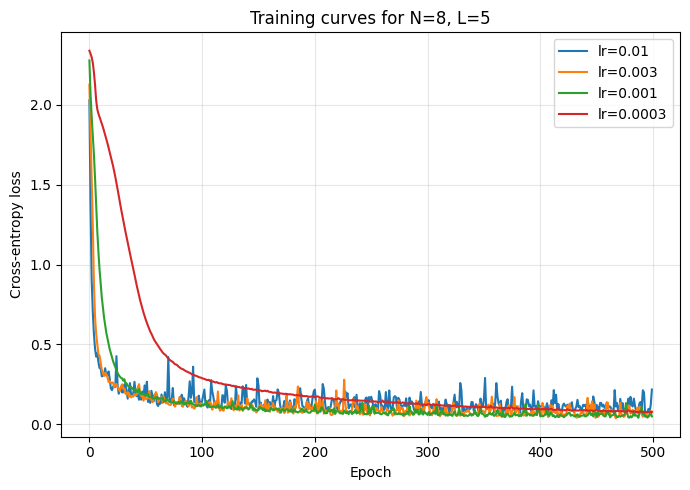


Best learning rate based on test accuracy: 0.003
Best test accuracy: 0.9835
Saved best model weights to best_model_N8_L5.pth


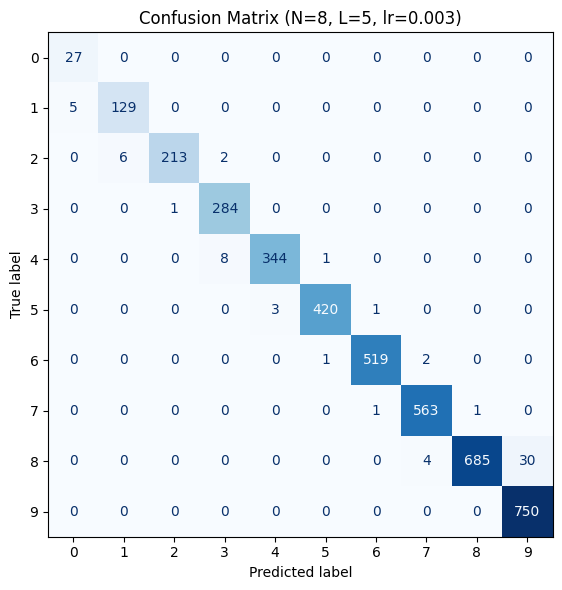

In [11]:
# --------------------------------------------------
# Search for best learning rate with fixed N = 8 and L = 5
# --------------------------------------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rates = [1e-2, 3e-3, 1e-3, 3e-4]
results = []

for lr in learning_rates:
    print("\n" + "="*60)
    print(f"Running experiment for lr = {lr}")
    res = run_single_experiment(N=8, L=5, lr=lr, epochs=500, batch_size=64, device=device)
    results.append((lr, res))

# Plot all loss curves together
plt.figure(figsize=(7, 5))
for lr, res in results:
    plt.plot(res['loss_history'], label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training curves for N=8, L=5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# save figure
plt.savefig("Training curves for N=8, L=5.png", dpi=300)

plt.show()

# Pick best by test accuracy
best_lr, best_res = max(results, key=lambda x: x[1]['test_acc'])
print(f"\nBest learning rate based on test accuracy: {best_lr}")
print(f"Best test accuracy: {best_res['test_acc']:.4f}")

# save best model weights locally
torch.save(best_res['model'].state_dict(), "best_model_N8_L5.pth")
print("Saved best model weights to best_model_N8_L5.pth")

plot_confusion_matrix(
    best_res['y_test'],
    best_res['test_pred'],
    best_res['num_classes'],
    title=f"Confusion Matrix (N=8, L=5, lr={best_lr})",
    save_path=f"Confusion Matrix (N=8, L=5, lr={best_lr}).png"
)


In [23]:
# --------------------------------------------------
# Sweep over N and L
# --------------------------------------------------

device = 'cuda' if torch.cuda.is_available() else 'cpu'
Ns = [5, 7, 10, 15]
Ls = [2, 5, 10]

# chose the best learning rate from the previous search 
lr = 0.003
epochs = 500

summary = []
best_acc = 0

for N in Ns:
    for L in Ls:
        print("\n" + "="*60)
        print(f"Running N={N}, L={L}")
        res = run_single_experiment(N=N, L=L, lr=lr, epochs=epochs, batch_size=64, device=device)
        summary.append({
            'N': N,
            'L': L,
            'train_acc': res['train_acc'],
            'test_acc': res['test_acc'],
            'final_loss': res['loss_history'][-1]
        })

        # save best model locally based on test accuracy
        if res['test_acc'] > best_acc:
            best_acc = res['test_acc']
            best_config = (N, L)

            torch.save(res['model'].state_dict(), f"best_model_N{N}_L{L}_lr{lr}.pth")

            print(f"New best model saved! N={N}, L={L}, test_acc={best_acc:.4f}")



Running N=5, L=2
Loading data from project2.dat
Epoch   50 | loss = 0.630025
Epoch  100 | loss = 0.432636
Epoch  150 | loss = 0.371296
Epoch  200 | loss = 0.306612
Epoch  250 | loss = 0.278596
Epoch  300 | loss = 0.264355
Epoch  350 | loss = 0.262629
Epoch  400 | loss = 0.246807
Epoch  450 | loss = 0.246377
Epoch  500 | loss = 0.243295

Final results for N=5, L=2, lr=0.003
Train accuracy = 0.8912
Test accuracy  = 0.8802
New best model saved! N=5, L=2, test_acc=0.8802

Running N=5, L=5
Loading data from project2.dat
Epoch   50 | loss = 0.293642
Epoch  100 | loss = 0.209715
Epoch  150 | loss = 0.169945
Epoch  200 | loss = 0.142866
Epoch  250 | loss = 0.159736
Epoch  300 | loss = 0.167767
Epoch  350 | loss = 0.132758
Epoch  400 | loss = 0.135179
Epoch  450 | loss = 0.141154
Epoch  500 | loss = 0.129096

Final results for N=5, L=5, lr=0.003
Train accuracy = 0.9605
Test accuracy  = 0.9547
New best model saved! N=5, L=5, test_acc=0.9547

Running N=5, L=10
Loading data from project2.dat
Epoc


Summary table:
    N     L    Train Acc     Test Acc   Final Loss
    5     2       0.8912       0.8802     0.243295
    5     5       0.9605       0.9547     0.129096
    5    10       0.9845       0.9752     0.082368
    7     2       0.9223       0.9095     0.186314
    7     5       0.9655       0.9543     0.061794
    7    10       0.9838       0.9760     0.056840
   10     2       0.9525       0.9410     0.069029
   10     5       0.9880       0.9785     0.044208
   10    10       0.9912       0.9850     0.062706
   15     2       0.9932       0.9832     0.031926
   15     5       0.9540       0.9463     0.101663
   15    10       0.9230       0.9223     0.236890


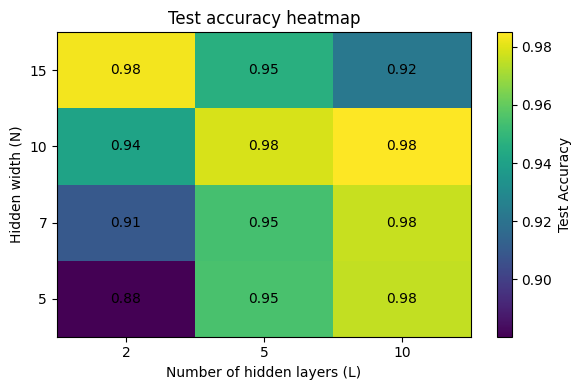

In [24]:
# Print summary
print("\nSummary table:")
print(f"{'N':>5} {'L':>5} {'Train Acc':>12} {'Test Acc':>12} {'Final Loss':>12}")
for row in summary:
    print(f"{row['N']:5d} {row['L']:5d} {row['train_acc']:12.4f} {row['test_acc']:12.4f} {row['final_loss']:12.6f}")

# Heatmap-like plot of test accuracy for different N and L
Ns = sorted(list(set([row['N'] for row in summary])))
Ls = sorted(list(set([row['L'] for row in summary])))

heatmap = np.zeros((len(Ns), len(Ls)))

for row in summary:
    i = Ns.index(row['N'])
    j = Ls.index(row['L'])
    heatmap[i, j] = row['test_acc']

# plot
plt.figure(figsize=(6, 4))
im = plt.imshow(heatmap, aspect='auto')
cbar = plt.colorbar(im)
cbar.set_label("Test Accuracy")
plt.xticks(range(len(Ls)), Ls)
plt.yticks(range(len(Ns)), Ns)
plt.xlabel("Number of hidden layers (L)")
plt.ylabel("Hidden width (N)")
plt.title("Test accuracy heatmap")
plt.gca().invert_yaxis()

# annotate values
for i in range(len(Ns)):
    for j in range(len(Ls)):
        val = heatmap[i, j]
        plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

plt.tight_layout()

# save figure
plt.savefig("Test accuracy heatmap.png", dpi=300)

plt.show()

There is no strict minimum N required to reach 0.9 accuracy, since even N = 2 achieves accuracy > 0.9 for large depth L. Increasing the depth L does improve the performance by enabling more complex nonlinear decision boundaries. But the gains saturate quickly, and very large L provides little additional gain or slightly degrade the performance. 